In [48]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import pandas as pd
import awkward as ak

In [49]:
fileData = uproot.open("Nueva_muestra.root")
tree = fileData["Events"]

print(tree.keys())

['run', 'luminosityBlock', 'event', 'nboostedTau', 'boostedTau_chargedIso', 'boostedTau_eta', 'boostedTau_leadTkDeltaEta', 'boostedTau_leadTkDeltaPhi', 'boostedTau_leadTkPtOverTauPt', 'boostedTau_mass', 'boostedTau_neutralIso', 'boostedTau_phi', 'boostedTau_photonsOutsideSignalCone', 'boostedTau_pt', 'boostedTau_puCorr', 'boostedTau_rawAntiEle2018', 'boostedTau_rawIso', 'boostedTau_rawIsodR03', 'boostedTau_rawMVAnewDM2017v2', 'boostedTau_rawMVAoldDM2017v2', 'boostedTau_rawMVAoldDMdR032017v2', 'boostedTau_charge', 'boostedTau_decayMode', 'boostedTau_jetIdx', 'boostedTau_rawAntiEleCat2018', 'boostedTau_idAntiEle2018', 'boostedTau_idAntiMu', 'boostedTau_idMVAnewDM2017v2', 'boostedTau_idMVAoldDM2017v2', 'boostedTau_idMVAoldDMdR032017v2', 'CaloMET_phi', 'CaloMET_pt', 'CaloMET_sumEt', 'ChsMET_phi', 'ChsMET_pt', 'ChsMET_sumEt', 'nCorrT1METJet', 'CorrT1METJet_area', 'CorrT1METJet_eta', 'CorrT1METJet_muonSubtrFactor', 'CorrT1METJet_phi', 'CorrT1METJet_rawPt', 'DeepMETResolutionTune_phi', 'DeepM

In [50]:
muon_keys = [key for key in tree.keys() if "Muon" in key]

print(muon_keys)

['Jet_nMuons', 'L1PreFiringWeight_Muon_Nom', 'L1PreFiringWeight_Muon_StatDn', 'L1PreFiringWeight_Muon_StatUp', 'L1PreFiringWeight_Muon_SystDn', 'L1PreFiringWeight_Muon_SystUp', 'nMuon', 'Muon_dxy', 'Muon_dxyErr', 'Muon_dxybs', 'Muon_dz', 'Muon_dzErr', 'Muon_eta', 'Muon_ip3d', 'Muon_jetPtRelv2', 'Muon_jetRelIso', 'Muon_mass', 'Muon_miniPFRelIso_all', 'Muon_miniPFRelIso_chg', 'Muon_pfRelIso03_all', 'Muon_pfRelIso03_chg', 'Muon_pfRelIso04_all', 'Muon_phi', 'Muon_pt', 'Muon_ptErr', 'Muon_segmentComp', 'Muon_sip3d', 'Muon_softMva', 'Muon_tkRelIso', 'Muon_tunepRelPt', 'Muon_mvaLowPt', 'Muon_mvaTTH', 'Muon_charge', 'Muon_jetIdx', 'Muon_nStations', 'Muon_nTrackerLayers', 'Muon_pdgId', 'Muon_tightCharge', 'Muon_fsrPhotonIdx', 'Muon_highPtId', 'Muon_highPurity', 'Muon_inTimeMuon', 'Muon_isGlobal', 'Muon_isPFcand', 'Muon_isStandalone', 'Muon_isTracker', 'Muon_jetNDauCharged', 'Muon_looseId', 'Muon_mediumId', 'Muon_mediumPromptId', 'Muon_miniIsoId', 'Muon_multiIsoId', 'Muon_mvaId', 'Muon_mvaLowPtI

In [51]:
branches = [
    "nMuon",
    "Muon_pt",
    "Muon_eta",
    "Muon_phi",
    "Muon_mass",
    "Muon_charge",
    "Muon_isGlobal"
]

In [52]:
data = tree.arrays(branches, library="ak")

In [53]:
mask = data["nMuon"] >= 2
data = data[mask]

In [54]:
mu1_pt  = data["Muon_pt"][:, 0]
mu2_pt  = data["Muon_pt"][:, 1]

mu1_eta = data["Muon_eta"][:, 0]
mu2_eta = data["Muon_eta"][:, 1]

mu1_phi = data["Muon_phi"][:, 0]
mu2_phi = data["Muon_phi"][:, 1]

mu1_mass = data["Muon_mass"][:, 0]
mu2_mass = data["Muon_mass"][:, 1]

mu1_charge = data["Muon_charge"][:, 0]
mu2_charge = data["Muon_charge"][:, 1]

mu1_isGlobal = data["Muon_isGlobal"][:, 0]
mu2_isGlobal = data["Muon_isGlobal"][:, 1]

In [55]:
df = pd.DataFrame({
    "mu1_pt": ak.to_numpy(mu1_pt),
    "mu2_pt": ak.to_numpy(mu2_pt),
    "mu1_eta": ak.to_numpy(mu1_eta),
    "mu2_eta": ak.to_numpy(mu2_eta),
    "mu1_phi": ak.to_numpy(mu1_phi),
    "mu2_phi": ak.to_numpy(mu2_phi),
    "mu1_mass": ak.to_numpy(mu1_mass),
    "mu2_mass": ak.to_numpy(mu2_mass),
    "mu1_charge": ak.to_numpy(mu1_charge),
    "mu2_charge": ak.to_numpy(mu2_charge),
    "mu1_isGlobal": ak.to_numpy(mu1_isGlobal),
    "mu2_isGlobal": ak.to_numpy(mu2_isGlobal)
})

In [56]:
df.head(10)

,mu1_pt,mu2_pt,mu1_eta,mu2_eta,mu1_phi,mu2_phi,mu1_mass,mu2_mass,mu1_charge,mu2_charge,mu1_isGlobal,mu2_isGlobal
0,11.845131,7.362170,-1.250732,-1.291504,0.263306,0.384888,0.105713,0.105713,1,1,False,True
1,33.573231,12.580651,1.647705,-0.117661,-1.190186,2.266113,0.105713,0.105713,1,-1,True,True
2,52.556774,42.794273,-1.429199,-1.901611,-2.723145,1.170410,0.105713,0.105713,-1,1,True,True
3,48.202980,3.778744,-1.553955,-1.979248,2.590820,2.323730,0.105713,0.105713,1,1,True,True
4,46.991871,43.490055,-2.278320,-1.619141,2.479492,-0.568481,0.105713,0.105713,-1,1,True,True
5,28.536793,26.835854,-1.869141,-0.338989,-2.602539,0.686768,0.105713,0.105713,-1,1,True,True
6,50.203129,38.603405,-0.656128,-1.013428,1.626221,-1.705811,0.105713,0.105713,-1,1,True,True
7,27.391069,6.912515,-0.138458,0.220764,2.780273,-0.500610,0.105713,0.105713,-1,1,True,True
8,29.146208,4.492096,-1.255371,0.946533,-3.071777,2.072754,0.105713,0.105713,1,1,True,True
9,17.252045,16.359312,0.147797,0.211212,2.233887,2.218750,0.105713,0.105713,1,-1,True,True


In [57]:
df.describe()

,mu1_pt,mu2_pt,mu1_eta,mu2_eta,mu1_phi,mu2_phi,mu1_mass,mu2_mass,mu1_charge,mu2_charge
count,2.402136e+06,2.402136e+06,2.402136e+06,2.402136e+06,2.402136e+06,2.402136e+06,2.402136e+06,2.402136e+06,2.402136e+06,2.402136e+06
mean,5.149033e+01,1.734583e+01,3.114367e-03,3.527666e-03,-8.651097e-03,-7.120741e-03,1.057056e-01,1.057048e-01,7.296007e-03,6.942155e-03
std,3.501427e+03,2.285447e+01,1.229487e+00,1.267719e+00,1.812520e+00,1.812193e+00,7.521479e-05,2.072643e-05,9.999736e-01,9.999761e-01
min,3.005917e+00,3.000017e+00,-8.871094e+00,-6.463867e+00,-3.141602e+00,-3.141602e+00,0.000000e+00,1.055908e-01,-1.000000e+00,-1.000000e+00
25%,1.858252e+01,8.528119e+00,-1.006836e+00,-1.068604e+00,-1.575195e+00,-1.571777e+00,1.057129e-01,1.057129e-01,-1.000000e+00,-1.000000e+00
50%,2.585567e+01,1.292016e+01,1.092553e-03,1.848102e-03,-1.197243e-02,-9.793282e-03,1.057129e-01,1.057129e-01,1.000000e+00,1.000000e+00
75%,4.061288e+01,2.274600e+01,1.015869e+00,1.078125e+00,1.560059e+00,1.557861e+00,1.057129e-01,1.057129e-01,1.000000e+00,1.000000e+00
max,3.806496e+06,1.243271e+04,9.363281e+00,1.002344e+01,3.141602e+00,3.141602e+00,1.397705e-01,1.057129e-01,1.000000e+00,1.000000e+00


In [58]:
df['M2'] = 2*df['mu1_pt']*df['mu2_pt']*(np.cosh(df['mu1_eta'] - df['mu2_eta']) - np.cos(df['mu1_phi'] - df['mu2_phi']))

df['M'] = np.sqrt(df['M2'])

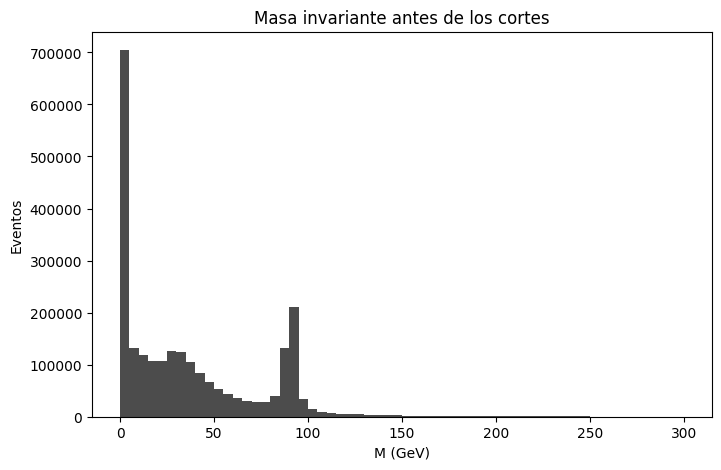

In [59]:
plt.figure(figsize=(8,5))
plt.hist(df['M'].dropna(), bins=60, range=(0,300), color='black', alpha=0.7)
plt.xlabel('M (GeV)')
plt.ylabel('Eventos')
plt.title('Masa invariante antes de los cortes')
plt.show()

In [60]:
flow = {}
flow['Sin cortes'] = len(df)

In [61]:
cut_pt = df[(df['mu1_pt'] > 20) &
 (df['mu2_pt'] > 20)]

flow['pT > 20 GeV'] = len(cut_pt)

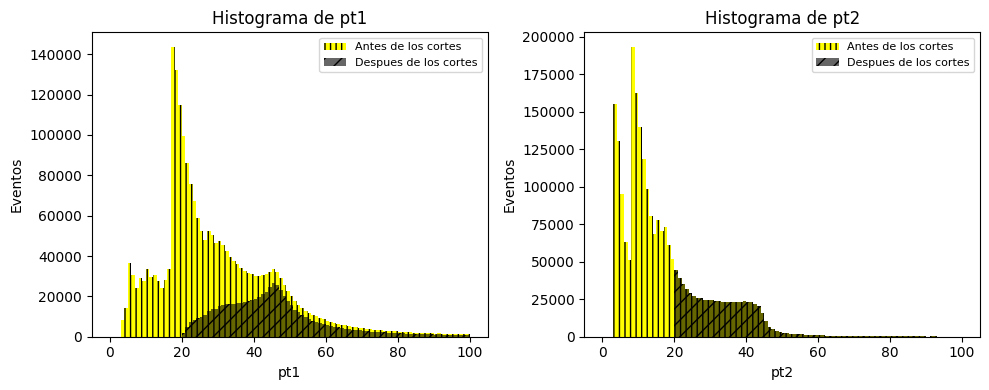

In [62]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title('Histograma de pt1')
rango_pt1 = (0, 100)
plt.hist(df['mu1_pt'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_pt1, label= 'Antes de los cortes')
plt.hist(cut_pt['mu1_pt'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_pt1, label= 'Despues de los cortes')
plt.xlabel('pt1')
plt.ylabel('Eventos')
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
plt.title('Histograma de pt2')
rango_pt2 = (0, 100)
plt.hist(df['mu2_pt'].dropna(), bins=100,color='yellow', hatch = '|||',range=rango_pt2, label= 'Antes de los cortes')
plt.hist(cut_pt['mu2_pt'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_pt2, label= 'Despues de los cortes')
plt.xlabel('pt2')
plt.ylabel('Eventos')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [63]:
cut_eta = cut_pt[
    (np.abs(cut_pt['mu1_eta'])<2.1) &
    (np.abs(cut_pt['mu2_eta'])<2.1)]

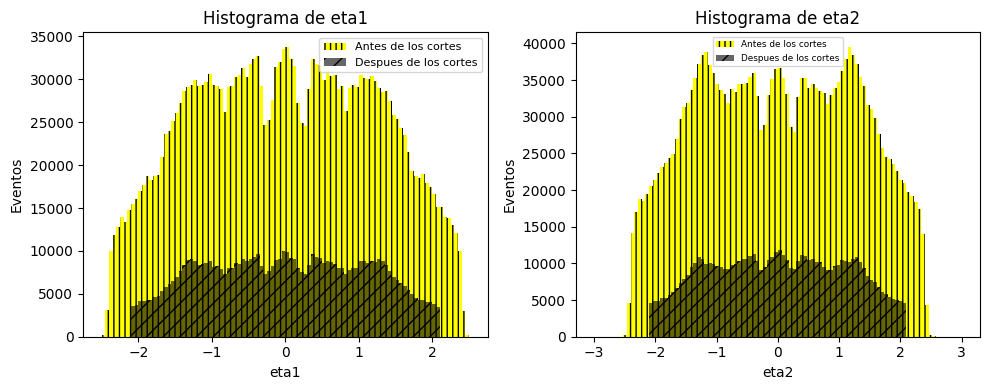

In [64]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title('Histograma de eta1')
rango_eta1=(-2.5,2.5)
plt.hist(df['mu1_eta'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_eta1, label= 'Antes de los cortes')
plt.hist(cut_eta['mu1_eta'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_eta1, label= 'Despues de los cortes')
plt.xlabel('eta1')
plt.ylabel('Eventos')
plt.legend(fontsize=8)



plt.subplot(1, 2, 2)
plt.title('Histograma de eta2')
rango_eta2=(-3,3)
plt.hist(df['mu2_eta'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_eta2, label= 'Antes de los cortes')
plt.hist(cut_eta['mu2_eta'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_eta2, label= 'Despues de los cortes')
plt.xlabel('eta2')
plt.ylabel('Eventos')
plt.legend(fontsize=6.4)


plt.tight_layout()
plt.show()

In [65]:
cut_charge = cut_eta[cut_eta['mu1_charge'] + cut_eta['mu2_charge'] == 0]

flow['Cargas opuestas'] = len(cut_charge)

In [66]:
cut_type = cut_charge[
    (cut_charge['mu1_isGlobal'] == 'G') &
    (cut_charge['mu2_isGlobal'] == 'G')]

flow['Global–Global'] = len(cut_type)

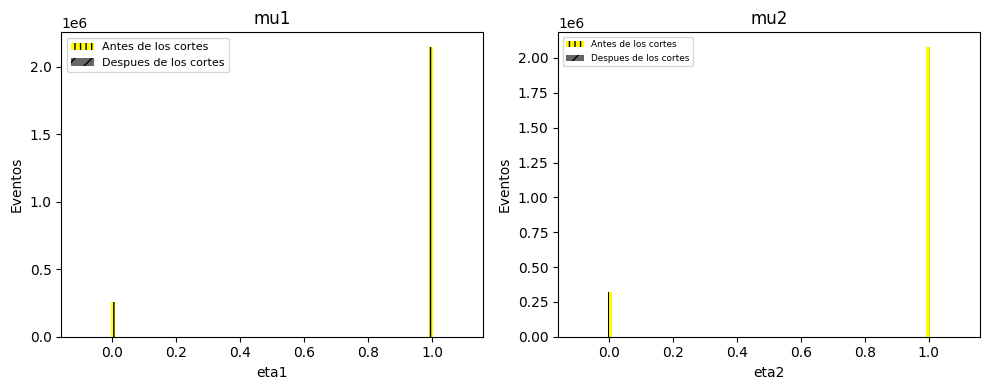

In [75]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title('mu1')
rango_eta1=(-0.1,1.1)
plt.hist(df['mu1_isGlobal'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_eta1, label= 'Antes de los cortes')
plt.hist(cut_type['mu1_isGlobal'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_eta1, label= 'Despues de los cortes')
plt.xlabel('eta1')
plt.ylabel('Eventos')
plt.legend(fontsize=8)



plt.subplot(1, 2, 2)
plt.title('mu2')
rango_eta2=(-0.1,1.1)
plt.hist(df['mu2_isGlobal'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_eta2, label= 'Antes de los cortes')
plt.hist(cut_type['mu2_isGlobal'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_eta2, label= 'Despues de los cortes')
plt.xlabel('eta2')
plt.ylabel('Eventos')
plt.legend(fontsize=6.4)

plt.tight_layout()
plt.show()

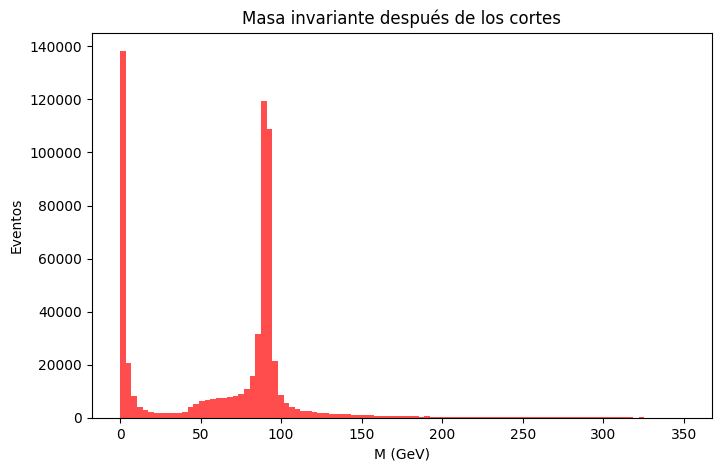

In [68]:
# Filtrar df por los cortes de eta y pt
cut_eta = df[
    (np.abs(df['mu1_eta']) < 2.1) &
    (np.abs(df['mu2_eta']) < 2.1) &
    (df['mu1_pt'] > 20) &
    (df['mu2_pt'] > 20)]

plt.figure(figsize=(8,5))
plt.hist(cut_eta['M'].dropna(), bins=100, range = (0,350), color='red', alpha=0.7)
plt.xlabel('M (GeV)')
plt.ylabel('Eventos')
plt.title('Masa invariante después de los cortes')
plt.show()


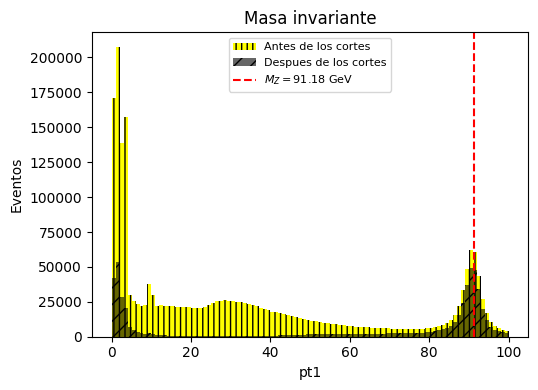

In [76]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title('Masa invariante')
rango = (0, 100)
plt.hist(df['M'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango, label= 'Antes de los cortes')
plt.hist(cut_eta['M'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango, label= 'Despues de los cortes')
plt.axvline(91.18, color='red', linestyle='--', label=r'$M_{Z} = 91.18$ GeV')
plt.xlabel('pt1')
plt.ylabel('Eventos')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [70]:
flow = {
    'Sin cortes': len(df),
    'pT > 20': len(cut_pt),
    '|eta| < 2.1': len(cut_eta)}

cutflow = pd.DataFrame.from_dict(flow, orient='index', columns=['Eventos'])
print(cutflow)

             Eventos
Sin cortes   2402136
pT > 20       710856
|eta| < 2.1   623251


In [71]:
cutflow['Eficiencia (%)'] = 100 * cutflow['Eventos'] / cutflow.iloc[0,0]
print(cutflow)

             Eventos  Eficiencia (%)
Sin cortes   2402136      100.000000
pT > 20       710856       29.592663
|eta| < 2.1   623251       25.945700


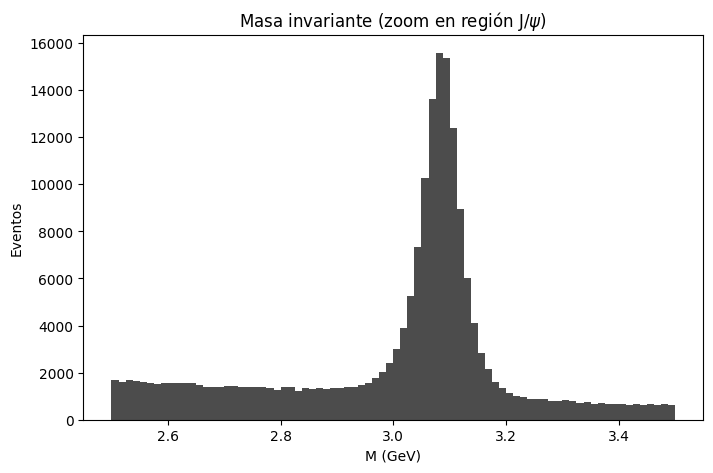

In [72]:
plt.figure(figsize=(8,5))
plt.hist(df['M'].dropna(), bins=80, range=(2.5, 3.5), color='black', alpha=0.7)
plt.xlabel('M (GeV)')
plt.ylabel('Eventos')
plt.title(r'Masa invariante (zoom en región J/$\psi$)')
plt.show()

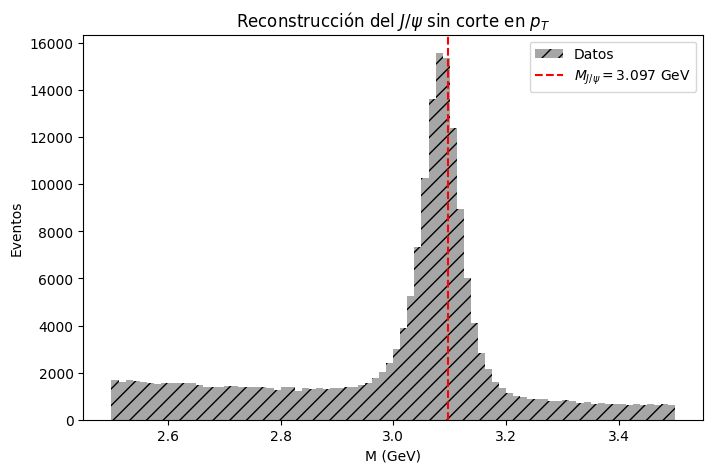

In [73]:
plt.figure(figsize=(8,5))


plt.hist(df['M'].dropna(), bins=80, range=(2.5, 3.5), hatch = '//' , color='gray', alpha=0.7, label='Datos')
plt.axvline(3.097, color='red', linestyle='--', label=r'$M_{J/\psi} = 3.097$ GeV')
plt.xlabel('M (GeV)')
plt.ylabel('Eventos')
plt.title(r'Reconstrucción del $J/\psi$ sin corte en $p_T$')
plt.legend()
plt.show()